# Text Preprocessing

Notebook ini merupakan kelanjutan dari tugas *web crawling* (Tugas 1) yang mengambil artikel berita dari detik.com (`dataset_berita_detik.csv`). Sesuai dengan spesifikasi tugas, terdapat **empat inti utama** yang akan diselesaikan dalam *notebook* ini:

1. **Preprocessing (Praproses):** Membersihkan teks mentah dari artefak karakter, tanda baca, simbol tak bermakna, serta menormalkan kata tidak baku (slang) tanpa merusak nama entitas penting (seperti nama tokoh atau lokasi).
2. **Ekstraksi Fitur / Kata Unik:** Mengurai teks menjadi sekumpulan kosakata (*vocabulary*) unik yang merepresentasikan keseluruhan korpus berita.
3. **Representasi TF-IDF:** Mengonversi data teks menjadi representasi angka atau matriks bobot matematis menggunakan metode Term Frequency-Inverse Document Frequency (TF-IDF).
4. **Reduksi Dimensi (PCA):** Melakukan teknik Principal Component Analysis (PCA) pada data TF-IDF untuk menyusutkan ribuan dimensi fitur (kata) menjadi dua dimensi saja, sehingga pola pemisahan antarkategori berita dapat divisualisasikan secara grafis.

Seluruh proses ini dirancang agar siap dipublikasikan (termasuk penyimpanan *file* hasil di *root directory*) tanpa melakukan permintaan jaringan (*network request*) baru.

---

## Tahap 1: Eksplorasi Data Awal

### Membaca Dataset

Pada tahap ini, kita menggunakan *library* **`pandas`**. `pandas` dipilih karena merupakan standar industri di Python untuk manipulasi data tabular. Fungsi `pd.read_csv()` memungkinkan kita memuat dataset teks ke dalam struktur *DataFrame* yang mudah diiris, difilter, dan dianalisis statistiknya.

In [31]:
import pandas as pd

# Membaca data langsung dari direktori utama
df = pd.read_csv("dataset_berita_detik.csv")
print(f"Dimensi data: {df.shape}")
df.info()

Dimensi data: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          200 non-null    int64 
 1   isi_berita  200 non-null    object
 2   label       200 non-null    object
 3   url         200 non-null    object
dtypes: int64(1), object(3)
memory usage: 6.4+ KB


### Pemeriksaan Integritas Data

Sebelum diolah, kita wajib memvalidasi apakah data hasil *crawling* memiliki anomali seperti nilai kosong (`NaN`) atau baris duplikat. `pandas` menyediakan fungsi bawaan seperti `.isna()` dan `.duplicated()` yang sangat efisien untuk pengecekan level korpus.

In [32]:
display(df.head())

checks = pd.DataFrame({
    "Parameter Pengecekan": ["Total Baris", "Sel Kosong (NaN)", "Baris Duplikat", "URL Duplikat", "Integritas ID", "Distribusi Label"],
    "Hasil": [
        len(df),
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["url"].duplicated().sum(),
        "Urut & Lengkap" if list(df["id"]) == list(
            range(1, len(df) + 1)) else "Tidak Urut",
        " | ".join(f"{k}: {v}" for k, v in df["label"].value_counts().items())
    ],
})
display(checks)

,id,isi_berita,label,url
0,1,"Marc Marquez Disebut di Puncak Karier, Bahasan...",sport,https://sport.detik.com/moto-gp/d-8666386/marc...
1,2,Foto Sport Melihat dari Dekat Latihan Para Atl...,sport,https://sport.detik.com/fotosport/d-8666341/me...
2,3,"Ai Ogura Siap Comeback di MotoGP Austria, Engg...",sport,https://sport.detik.com/moto-gp/d-8666308/ai-o...
3,4,Ketum KONI Tutup Program Sport Diplomacy Indon...,sport,https://sport.detik.com/g-sport/d-8666151/ketu...
4,5,"Usai Dilantik KONI, Ini Rencana Pengurus Pusat...",sport,https://sport.detik.com/sport-lain/d-8666068/u...


,Parameter Pengecekan,Hasil
0,Total Baris,200
1,Sel Kosong (NaN),0
2,Baris Duplikat,0
3,URL Duplikat,0
4,Integritas ID,Urut & Lengkap
5,Distribusi Label,sport: 100 | finance: 100


### Distribusi Panjang Teks

Panjang dokumen (jumlah karakter dan kata) dianalisis untuk mendeteksi *outlier* (pencilan), misalnya dokumen yang isinya hanya judul atau dokumen yang terlampau panjang karena memuat data tabel.

In [33]:
# Menghitung panjang karakter dan kata per baris menggunakan accessor .str dari pandas
stats = (df.assign(panjang_karakter=df["isi_berita"].str.len(),
                   jumlah_kata=df["isi_berita"].str.split().str.len())
         .groupby("label")[["panjang_karakter", "jumlah_kata"]]
         .agg(["min", "median", "max"]))
display(stats)

panjang_karakter               jumlah_kata            
                     min  median   max         min median  max
label                                                         
finance              224  2331.0  7078          31  326.0  953
sport                246  2026.5  7149          35  294.5  974

### Visualisasi Sebaran Panjang Artikel

Untuk melihat rentang distribusi teks, kita menggunakan **`matplotlib`** dan **`seaborn`**. `matplotlib` adalah fondasi grafik di Python, sementara `seaborn` membungkusnya untuk menghasilkan *boxplot* yang secara visual langsung menunjukkan letak kuartil, median, dan pencilan (*outliers*) dari teks kategori *sport* maupun *finance*.

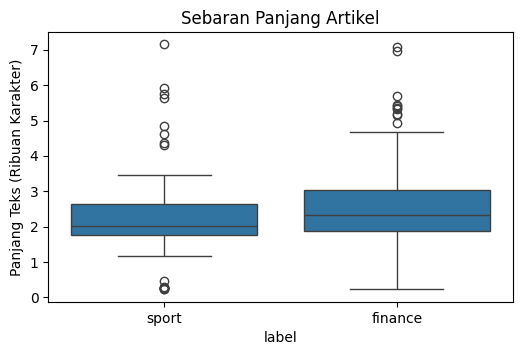

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=df, x="label", y=df["isi_berita"].str.len() / 1000, ax=ax)
ax.set_ylabel("Panjang Teks (Ribuan Karakter)")
ax.set_title("Sebaran Panjang Artikel")
plt.show()

---

## Tahap 2: Pembersihan & Analisis Bahasa

Langkah krusial pertama dalam praproses adalah menghilangkan "gangguan" teknis sebelum masuk ke level leksikal (kata).

### Menangani Artefak Karakter Non-ASCII

Sistem berita daring sering menyimpan karakter di luar standar ASCII (kode Unicode > 127), seperti huruf beraksen (é, í), spasi *non-breaking*, atau emoji. Kita perlu mendeteksinya terlebih dahulu.

In [35]:
def chars_outside_ascii(text):
    return sorted({c for c in text if ord(c) > 127})


rows = []
for _, r in df.iterrows():
    extra = chars_outside_ascii(r["isi_berita"])
    if extra:
        rows.append({"id": r["id"], "label": r["label"],
                    "karakter_ditemukan": " ".join(extra)})

display(pd.DataFrame(rows))

,id,label,karakter_ditemukan
0,36,sport,— ™ 🇲 🇸 🏁 🤯
1,46,sport,— ™ 🇲 🇸 🏁 😱
2,47,sport,— ™ 🇲 🇸 🏁 🏆
3,197,finance,•


### Normalisasi Karakter (Unicode)

Untuk membersihkan karakter aksen tanpa menghapus huruf utamanya (misalnya "Nestlé" menjadi "Nestle" bukan "Nestl"), kita menggunakan modul bawaan Python **`unicodedata`**. 

Fungsi `unicodedata.normalize("NFD", text)` memisahkan huruf dasar dengan tanda aksennya (diakritik), lalu kita filter aksen tersebut. Ini mempertahankan makna nama tokoh/brand asing.

In [36]:
import unicodedata


def normalize_letters(text):
    # NFD memecah karakter seperti 'é' menjadi 'e' dan tanda aksen (combining character)
    decomposed = unicodedata.normalize("NFD", text)
    # Memfilter hanya huruf utamanya saja
    text = "".join(c for c in decomposed if not unicodedata.combining(c))
    # Menyamakan tanda hubung non-breaking
    return text.replace("\u2011", "-").replace("\u2010", "-")


try:
    sample = df.set_index("id").loc[[19, 57, 66, 89, 91, 181], "isi_berita"]
    display(pd.DataFrame({
        "ID Artikel": sample.index,
        "Teks Asli": [t[:90] for t in sample],
        "Setelah Normalisasi": [normalize_letters(t)[:90] for t in sample],
    }))
except KeyError:
    pass

,ID Artikel,Teks Asli,Setelah Normalisasi
0,19,"Foto Sport Dari Mimika, Anak Papua Mengejar Mi...","Foto Sport Dari Mimika, Anak Papua Mengejar Mi..."
1,57,"Tebak 4 Sirkuit MotoGP, 3 Peserta Ini Berhasil...","Tebak 4 Sirkuit MotoGP, 3 Peserta Ini Berhasil..."
2,66,Hasil Kualifikasi Moto3 San Marino: Veda Ega S...,Hasil Kualifikasi Moto3 San Marino: Veda Ega S...
3,89,Men's World Tennis Championship: Cuma Satu Wak...,Men's World Tennis Championship: Cuma Satu Wak...
4,91,Nova Widianto Pede Amri/Nita Sumbang Medali di...,Nova Widianto Pede Amri/Nita Sumbang Medali di...
5,181,Purbaya Sudah Curiga Bakal Dicopot: Kansnya 50...,Purbaya Sudah Curiga Bakal Dicopot: Kansnya 50...


### Sensus Token Naif & Analisis Serpihan Huruf

Dalam mengekstrak fitur nanti, kata-kata yang terlalu pendek (1 atau 2 huruf) biasanya tidak memiliki bobot makna spesifik (TF-IDF). Kita melakukan perhitungan awal menggunakan modul **`collections.Counter`**. 

`Counter` sangat efisien secara komputasi untuk menghitung frekuensi kemunculan setiap kata di dalam korpus berjumlah puluhan ribu kata, sementara modul **`re`** (Regular Expression) digunakan untuk memecah teks (*tokenisasi*) berdasarkan pola alfabetis.

In [37]:
import re
from collections import Counter


def naive_tokens(text):
    # Hanya mengambil huruf alfabetis dan mengubahnya menjadi huruf kecil (lowercase)
    return re.sub(r"[^a-z\s]", " ", text.lower()).split()


naive_corpus = [word for doc in df["isi_berita"] for word in naive_tokens(doc)]
naive_counts = Counter(naive_corpus)

single_chars = {w: n for w, n in naive_counts.items() if len(w) == 1}
double_chars = {w: n for w, n in naive_counts.items() if len(w) == 2}
total_tokens = len(naive_corpus)

display(pd.DataFrame({
    "Metrik": ["Total Token", "Kosakata Unik", "Token 1 Huruf", "Token 2 Huruf"],
    "Jumlah": [total_tokens, len(naive_counts), sum(single_chars.values()), sum(double_chars.values())],
    "Persentase": ["100%", f"{100 * len(naive_counts) / total_tokens:.2f}%",
                   f"{100 * sum(single_chars.values()) / total_tokens:.2f}%",
                   f"{100 * sum(double_chars.values()) / total_tokens:.2f}%"],
}))

,Metrik,Jumlah,Persentase
0,Total Token,66227,100%
1,Kosakata Unik,7327,11.06%
2,Token 1 Huruf,240,0.36%
3,Token 2 Huruf,2773,4.19%


### Inspeksi Token 1 Huruf

Apakah token 1 huruf memiliki makna? Regex (`re.finditer`) digunakan di sini untuk mencari letak persis sebuah huruf tunggal di dalam teks asli (konteks), guna memastikan kita tidak membuang informasi berharga.

In [38]:
display(pd.DataFrame([{"Huruf": w, "Frekuensi": n} for w, n in sorted(
    single_chars.items(), key=lambda x: -x[1])]).head(10))


def get_context(texts, token, window=25):
    for text in texts:
        for m in re.finditer(r"(?<![A-Za-z])" + token + r"(?![A-Za-z])", text, re.IGNORECASE):
            start = max(0, m.start() - window)
            return text[start:m.end() + window].replace("\n", " ")


display(pd.DataFrame([{"Huruf": w, "Konteks Asli": get_context(list(df["isi_berita"]), w)}
                      for w in ["x", "u", "i", "s", "b", "a", "d", "h", "m"]]))

,Huruf,Frekuensi
0,m,31
1,s,29
2,p,21
3,a,20
4,u,18
5,i,18
6,e,17
7,v,15
8,x,12
9,q,10


,Huruf,Konteks Asli
0,x,Roster Timnas Basket 3x3 Putri Indonesia di Asia
1,u,"bola basket beregu putri U-15, bulu tangkis be..."
2,i,kal Pertama (Marsma) TNI I.B. Ngurah Mardika P...
3,s,alking lunges dan farmer's carry. Wietrzyk tet...
4,b,l Pertama (Marsma) TNI I.B. Ngurah Mardika Put...
5,a,5 September 2026 di Hall A Gelanggang Mahasisw...
6,d,"onesia tergabung di Pool D bersama Singapura, ..."
7,h,None
8,m,hampion Reborn Jogja) 4. M. Ramdani Mubarok - ...


Ternyata huruf tunggal berasal dari singkatan atau ukuran (contoh: "3x3", "U-15"). Oleh karena itu, huruf tunggal aman untuk dihapus.

### Inspeksi Token 2 Huruf & Filter Stopword

Untuk token 2 huruf, kita akan menyaringnya. Kita menggunakan *library* **`Sastrawi`** (`StopWordRemoverFactory`). `Sastrawi` dipilih karena menyediakan daftar leksikon standar *stopword* (kata hubung/fungsi) bahasa Indonesia baku yang sering muncul namun tidak membawa bobot semantik (seperti "di", "ke", "ya").

In [39]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
rows = []
for w, n in sorted(double_chars.items(), key=lambda x: -x[1]):
    if n >= 3:
        rows.append({"Token": w, "Frekuensi": n,
                    "Konteks": get_context(list(df["isi_berita"]), w)})
display(pd.DataFrame(rows).head(10))


# Mengambil daftar stopword Sastrawi ke dalam set() untuk pencarian (lookup) yang lebih cepat
id_stopwords = set(StopWordRemoverFactory().get_stop_words())
valid_double = [w for w, n in double_chars.items() if n >= 3]

display((pd.DataFrame({
    "Token": valid_double,
    "Frekuensi": [double_chars[w] for w in valid_double],
    "Termasuk Stopword Sastrawi?": [w in id_stopwords for w in valid_double]
}).sort_values("Frekuensi", ascending=False)).head(10))

,Token,Frekuensi,Konteks
0,di,1398,"Marc Marquez Disebut di Puncak Karier, Bahasan C"
1,ke,347,Ai Ogura bersiap kembali ke arena MotoGP pada ...
2,rp,224,angga senilai lebih dari Rp 4 juta. Tas beruku...
3,ia,124,n dari maksimal 37 poin. Ia pun disebut sedang...
4,ya,78,ar lagi. Bagas juga sama ya sudah kita hajar s...
5,pt,72,"epada Djarum Foundation, PT Bank Rakyat Indone..."
6,pb,67,"a tim teknis khusus dari PB PASI, sehingga mat..."
7,ri,32,umni PPRA LXII Lemhannas RI itu. Tak hanya atl...
8,as,32,"ak atas hadiah 930 dolar AS, serta tambahan 15..."
9,us,31,Zverev Juara US Open 2026 Usai Kalahkan


,Token,Frekuensi,Termasuk Stopword Sastrawi?
0,di,1398,True
4,ke,347,True
11,rp,224,False
1,ia,124,True
10,ya,78,True
36,pt,72,False
9,pb,67,False
19,ri,32,False
34,as,32,False
30,us,31,False


### Evaluasi Bahasa Asing

Kita menggunakan *library* **`langid`** untuk mengklasifikasikan bahasa (Indonesia vs Inggris/lainnya). `langid` sangat ringan dan didesain secara spesifik untuk memprediksi bahasa berdasarkan n-gram probabilitas statistik. Kita harus memutuskan: apakah kata serapan Inggris dalam berita perlu diterjemahkan atau dibiarkan?

In [40]:
import langid

sentences, doc_ids = [], []
for _, row in df.iterrows():
    # Tokenisasi kalimat menggunakan regex
    parts = [p.strip() for p in re.split(
        r"(?<=[.!?])\s+|\n+", row["isi_berita"]) if p.strip()]
    sentences.extend(parts)
    doc_ids.extend([row["id"]] * len(parts))

# Menggunakan model prediktif langid
predicted_langs = [langid.classify(s)[0] for s in sentences]
lang_dist = Counter(predicted_langs)

display((pd.DataFrame({
    "Kode Bahasa": list(lang_dist),
    "Jumlah Kalimat": list(lang_dist.values()),
    "Proporsi": [f"{100 * k / len(sentences):.1f}%" for k in lang_dist.values()]
}).sort_values("Jumlah Kalimat", ascending=False)).head(10))

en_sentences = [{"ID": did, "Cuplikan Kalimat": s[:96] + "..."}
                for s, lang, did in zip(sentences, predicted_langs, doc_ids)
                if lang == "en" and len(s.split()) >= 8]
display(pd.DataFrame(en_sentences).head(10))

,Kode Bahasa,Jumlah Kalimat,Proporsi
0,id,4224,96.2%
1,en,165,3.8%


,ID,Cuplikan Kalimat
0,4,Ketum KONI Tutup Program Sport Diplomacy Indon...
1,38,"Bos Ducati, Davide Tardozzi tolak label favori..."
2,38,"Team Manager alias bos Ducati, Davide Tardozzi..."
3,42,Ailsie Elaina Sembiring - Kota Bogor (PB Champ...
4,42,Muhammad Deffran Alfarraz - Cirebon (PB Pandaw...
5,42,Kentaro Javas Kaivan Tsaqib - Kebumen (PB Cham...
6,42,Fawwaz Sani Adhipramana - Ponorogo (PB PMS Sol...
7,42,Baron Baswara Putra - Kota Yogyakarta (PB Cham...
8,42,Vicky Lee Alison - Tegal (PB Sinar Mutiara) 4....
9,42,Arnetta Safara Bilqish Sholeh - Kota Yogyakart...


Ternyata mayoritas yang terdeteksi sebagai bahasa Inggris adalah frasa nama entitas olahraga atau finansial. Mengubah atau menerjemahkannya justru akan merusak "fitur" informasi (misal: "Lakers" menjadi aneh jika diterjemahkan). Kesimpulannya: kita biarkan (preservasi) istilah asing tersebut.

In [41]:
test_words = ["dan", "di", "ke", "dalam", "pada",
              "akan", "juga", "bank", "saham", "untuk"]
display(pd.DataFrame({
    "Kata Indonesia": test_words,
    "Prediksi langid": [langid.classify(w)[0] for w in test_words]
}))

token_en = Counter()
for s, lang in zip(sentences, predicted_langs):
    if lang == "en" and len(s.split()) >= 8:
        token_en.update(re.findall(r"[A-Za-z]+", s.lower()))

all_words = Counter(w for t in df["isi_berita"]
                    for w in re.findall(r"[A-Za-z]+", t.lower()))
cap_words = Counter(w.lower() for t in df["isi_berita"] for w in re.findall(
    r"[A-Za-z]+", t) if w[0].isupper())

rows = []
for w, n_en in token_en.most_common(15):
    rows.append({"Kata Asing": w, "Muncul di Kalimat EN": n_en,
                "Total Korpus": all_words[w], "Kemunculan dg Kapital": cap_words[w]})
display(pd.DataFrame(rows))

,Kata Indonesia,Prediksi langid
0,dan,en
1,di,en
2,ke,en
3,dalam,en
4,pada,en
5,akan,en
6,juga,en
7,bank,en
8,saham,en
9,untuk,id


,Kata Asing,Muncul di Kalimat EN,Total Korpus,Kemunculan dg Kapital
0,s,13,29,3
1,pb,12,67,67
2,spa,9,9,9
3,gp,9,23,23
4,ducati,8,39,39
5,rc,8,8,8
6,wib,8,54,54
7,nr,8,9,9
8,champion,7,15,15
9,marquez,6,163,163


---

## Tahap 3: Preservasi Makna & Standarisasi Teks

### Mengamankan Token Komposit (Pola Khusus)

Menggunakan modul `re` (Regex), kita mendefinisikan *pattern* canggih untuk memblokir teks seperti URL (`http...`), Mata Uang (`Rp`, `US$`), Angka Romawi, dan huruf bercampur angka (`U-18`, `3x3`). Pola-pola ini akan diganti dengan spasi atau dipertahankan utuh sebelum tanda baca umum dihapus, sehingga fitur penting tidak terpecah menjadi serpihan.

In [42]:
url_pattern = re.compile(r"(?:https?://|www\.|pic\.twitter\.com/)\S+")
alnum_pattern = re.compile(r"\b(?=[A-Za-z]*\d)[A-Za-z0-9][A-Za-z0-9.*-]*\b")
currency_pattern = re.compile(
    r"\bRp\d[\d.,]*\b|\bUS\$\d[\d.,]*\b|\b\$\d[\d.,]*\b|\bRp\b|\bUS\$\b")
roman_pattern = re.compile(
    r"\b(?:iii|iv|vi{0,3}|i[ivx]{0,2}|v|x{1,3}|xi{0,3})\b", re.IGNORECASE)

display(pd.DataFrame({
    "Jenis Pola Regex": ["Tautan/URL", "Alfanumerik", "Mata Uang", "Angka Romawi"],
    "Jumlah Ekstraksi": [
        sum(len(url_pattern.findall(t)) for t in df["isi_berita"]),
        sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"]),
        sum(len(currency_pattern.findall(t)) for t in df["isi_berita"]),
        sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])
    ],
    "Contoh": ["pic.twitter.com/Zjx...", "3x3, U-18, 76ers", "Rp, US$", "IV, VIII, XI"]
}))


def block_composites(text):
    text = url_pattern.sub(" ", text)
    text = currency_pattern.sub(" ", text)
    text = alnum_pattern.sub(" ", text)
    text = roman_pattern.sub(" ", text)
    return text.replace("\u2011", "-")


def basic_clean(text):
    text = normalize_letters(block_composites(text))
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    return " ".join(w for w in text.split() if len(w) >= 2)


test_clean = [basic_clean(t) for t in df["isi_berita"]]
test_tokens = [w.lower() for doc in test_clean for w in doc.split()]
test_counts = Counter(test_tokens)

display(pd.DataFrame({
    "Skenario Evaluasi": ["Mentah (Naif)", "Setelah Proteksi & Filter Min. 2 Huruf"],
    "Total Kosakata Unik": [len(naive_counts), len(test_counts)],
    "Token 1 Huruf": [sum(single_chars.values()), sum(n for w, n in test_counts.items() if len(w) == 1)],
    "Token 2 Huruf": [sum(double_chars.values()), sum(n for w, n in test_counts.items() if len(w) == 2)]
}))

,Jenis Pola Regex,Jumlah Ekstraksi,Contoh
0,Tautan/URL,4,pic.twitter.com/Zjx...
1,Alfanumerik,3508,"3x3, U-18, 76ers"
2,Mata Uang,225,"Rp, US$"
3,Angka Romawi,56,"IV, VIII, XI"


,Skenario Evaluasi,Total Kosakata Unik,Token 1 Huruf,Token 2 Huruf
0,Mentah (Naif),7327,240,2773
1,Setelah Proteksi & Filter Min. 2 Huruf,7272,0,2444


### Sensus Nama Diri (Proper Nouns)

Ciri utama *Proper Noun* adalah penggunaan huruf kapital di *tengah* kalimat. Logika ini diimplementasikan untuk mengamankan fitur nama tokoh/organisasi agar tidak termodifikasi di tahap standarisasi slang.

In [43]:
def check_mid_sentence(text, pos):
    i = pos - 1
    while i >= 0 and text[i] in ' \n\t"\'":(':
        i -= 1
    return i >= 0 and text[i] not in '.!?;:(\u2013\u2014'


proper_nouns = Counter()
for text in df["isi_berita"]:
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        if len(w) >= 3 and w[0].isupper() and check_mid_sentence(text, m.start()):
            proper_nouns[w.lower()] += 1

display(pd.DataFrame({
    "Metrik Ekstraksi": ["Nama Unik", "Total Kemunculan Nama", "Nama Muncul >= 3 Kali"],
    "Nilai": [len(proper_nouns), sum(proper_nouns.values()), sum(1 for n in proper_nouns.values() if n >= 3)]
}))
display(pd.DataFrame([{"Kandidat Nama": w, "Frekuensi": n}
        for w, n in proper_nouns.most_common(15)]))

,Metrik Ekstraksi,Nilai
0,Nama Unik,3200
1,Total Kemunculan Nama,14169
2,Nama Muncul >= 3 Kali,1047


,Kandidat Nama,Frekuensi
0,indonesia,346
1,jakarta,280
2,artikel,197
3,motogp,167
4,marquez,140
5,anda,134
6,games,127
7,asian,106
8,purbaya,97
9,prabowo,94


### Standardisasi Slang Terkondisi

Kita memanfaatkan *library* **`indoNLP`** (`replace_slang`) yang memuat ribuan pemetaan kamus gaul/alay bahasa Indonesia. Namun, pengaplikasiannya diawasi ketat oleh algoritma penapis (filter) agar kata seperti "Pass" (nama produk/layanan) tidak diubah keliru menjadi "pas", atau istilah olahraga "Dunk" tidak berubah.

In [44]:
from indoNLP.preprocessing import replace_slang

slang_modifications = Counter()
exclude_words = {"dunk", "slam", "minta", "fans", "pala", "masukin"}


def protected_slang_replace(text):
    changes = []
    for m in re.finditer(r"[A-Za-z]+", text):
        w = m.group(0)
        norm_w = replace_slang(w.lower())

        # Bypass kata baku / masuk daftar eksklusi
        if norm_w == w.lower() or w.lower() in exclude_words:
            continue

        before = text[max(0, m.start() - 6):m.start()]
        after = text[m.end():m.end() + 6]

        # Guard rules: Mencegah kamus slang merusak nama akronim jurnalis, kata depan angka, dan proper nouns
        is_near_digit = bool(re.search(r"\d", before + after))
        is_reporter_code = bool(
            re.search(r"\(\w{2,6}/\w{2,6}\)", text[m.start() - 6:m.end() + 6]))
        looks_proper = (w.isupper() or any(c.isupper() for c in w[1:]) or
                        (w[:1].isupper() and w[1:].islower() and check_mid_sentence(text, m.start())))
        is_short_token = len(w) <= 2 and w.lower() not in id_stopwords

        if not (is_near_digit or is_reporter_code or looks_proper or is_short_token):
            changes.append((m.start(), m.end(), norm_w))
            slang_modifications[w.lower()] += 1

    out = list(text)
    for s, e, r in reversed(changes):
        out[s:e] = list(r)
    return "".join(out)


def final_cleanup(text):
    text = normalize_letters(block_composites(text))
    text = protected_slang_replace(text)
    # Penghapusan simbol tersisa selain alfabet
    text = re.sub(r"[^A-Za-z\s-]", " ", text)
    text = re.sub(r"-+", " ", text)
    words = [w for w in text.split() if len(w) >= 2]
    # Filter final terhadap token 2 huruf yang bukan stopwords
    return " ".join(w for w in words if not (len(w) == 2 and w.lower() not in id_stopwords))


corpus_final = [final_cleanup(t).split() for t in df["isi_berita"]]
corpus_word_freq = Counter(w.lower() for doc in corpus_final for w in doc)

changed_summary = []
for w, cnt in sorted(slang_modifications.items()):
    changed_summary.append({
        "Kata Asli (Slang)": w, "Frekuensi Diubah": cnt,
        "Bentuk Baku": replace_slang(w),
        "Di Korpus Akhir": corpus_word_freq.get(replace_slang(w), 0)
    })
display(pd.DataFrame(changed_summary))

,Kata Asli (Slang),Frekuensi Diubah,Bentuk Baku,Di Korpus Akhir
0,aja,3,saja,50
1,dapet,1,dapat,150
2,dibiarin,1,dibiarkan,3
3,gak,1,enggak,62
4,gimana,3,bagaimana,31
5,gini,1,begini,4
6,gitu,10,begitu,41
7,hub,4,hubungan,12
8,ikutin,1,mengikuti,34
9,kaya,7,kayak,9


---

## Tahap 4: Representasi Korpus & Reduksi Dimensi

### Ekstraksi Fitur Kata Unik (Vocabulary)

Langkah ini mencerminkan pencapaian objektif utama: mengekstrak seluruh kata unik yang akan bertindak sebagai **fitur (kolom)** bagi algoritma *machine learning*. Kita melihat seberapa spesifik kosakata masing-masing kategori label (*sport* vs *finance*).

In [45]:
sport_vocab = {w for doc, lbl in zip(
    corpus_final, df["label"]) if lbl == "sport" for w in doc}
finance_vocab = {w for doc, lbl in zip(
    corpus_final, df["label"]) if lbl == "finance" for w in doc}

display(pd.DataFrame({
    "Segmen Kelas": ["Sport", "Finance", "Irisan (Digunakan Keduanya)"],
    "Total Kata Unik (Fitur)": [len(sport_vocab), len(finance_vocab), len(sport_vocab & finance_vocab)],
}))
display(pd.DataFrame([{"Kata Teratas (Top Features)": w, "Frekuensi": n}
        for w, n in corpus_word_freq.most_common(15)]))

,Segmen Kelas,Total Kata Unik (Fitur)
0,Sport,5119
1,Finance,5418
2,Irisan (Digunakan Keduanya),1875


,Kata Teratas (Top Features),Frekuensi
0,di,1398
1,yang,1347
2,dan,1267
3,ini,903
4,dari,699
5,dengan,687
6,untuk,565
7,dalam,463
8,juga,423
9,pada,422


### Representasi dalam Matriks TF-IDF & Ekspor

Kita menggunakan kelas **`TfidfVectorizer`** dari *library* **`scikit-learn` (`sklearn`)**. Kelas ini secara otomatis melakukan dua hal krusial:
1. **Term Frequency (TF):** Menghitung seberapa sering sebuah kata muncul dalam satu dokumen.
2. **Inverse Document Frequency (IDF):** Menurunkan bobot kata yang muncul di *hampir semua* dokumen (seperti "dan", "atau"), dan menaikkan bobot kata yang spesifik/jarang (seperti "IHSG", "NBA").

Hasilnya berupa *Sparse Matrix* (Matriks Jarang). Karena mayoritas nilai sel matriks ini adalah 0 (sebuah dokumen hanya memuat sebagian kecil dari total kosakata), kita menggunakan fungsi **`scipy.sparse.save_npz`** untuk menyimpannya ke *disk*. Modul **`os`** dipakai untuk memverifikasi ukuran file.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import os

# token_pattern="\b\w\w+\b" digunakan untuk secara tegas mengekstrak token sepanjang minimal 2 karakter
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w\w+\b")

# Transformasi dokumen teks ke matriks bobot TF-IDF
X_tfidf = vectorizer.fit_transform([" ".join(doc) for doc in corpus_final])

# Ekspor File Matriks Sparse dan Referensinya (ke direktori utama / root)
sp.save_npz("tfidf_sparse.npz", X_tfidf)
pd.Series(vectorizer.get_feature_names_out()).to_csv(
    "tfidf_features.txt", index=False, header=False)
pd.DataFrame({"id": df["id"], "label": df["label"]}
             ).to_csv("tfidf_docs.csv", index=False)

display(pd.DataFrame({
    "File Dihasilkan": ["tfidf_sparse.npz", "tfidf_features.txt", "tfidf_docs.csv"],
    "Ukuran Disk (Bytes)": [os.path.getsize("tfidf_sparse.npz"),
                            os.path.getsize("tfidf_features.txt"),
                            os.path.getsize("tfidf_docs.csv")]
}))

,File Dihasilkan,Ukuran Disk (Bytes)
0,tfidf_sparse.npz,214357
1,tfidf_features.txt,66444
2,tfidf_docs.csv,2302


### Reduksi Dimensi Data dengan PCA

Matriks TF-IDF yang kita hasilkan memiliki ribuan dimensi (ribuan kata/kolom). Tidak mungkin memvisualisasikan data ribuan dimensi ke layar komputer. Oleh sebab itu, kita memakai teknik **Principal Component Analysis (PCA)** menggunakan **`sklearn.decomposition.PCA`**.

PCA mencari "garis diagonal/komponen utama" yang paling dapat menangkap perbedaan (*variance*) paling besar dalam data, lalu mereduksinya secara matematis menjadi cukup 2 dimensi (PC1 dan PC2) untuk ditaburkan (*scatter plot*) dalam diagram X dan Y.

,Komponen Utama,Rasio Varians yang Ditangkap
0,PC1 (Sumbu X),0.0415
1,PC2 (Sumbu Y),0.0312
2,Total Kumulatif,0.0727


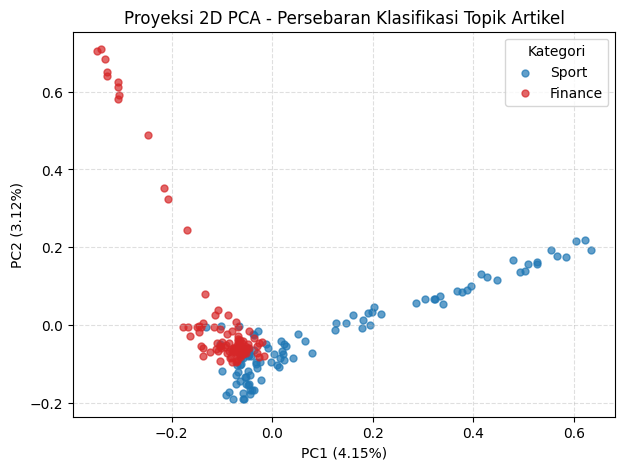

In [47]:
from sklearn.decomposition import PCA

# Inisiasi reduksi ke 2 komponen utama
pca_model = PCA(n_components=2, random_state=42)

# Mengkonversi ke array padat (dense) karena PCA standar membutuhkan memori dense
Z_pca = pca_model.fit_transform(X_tfidf.toarray())
explained_vars = pca_model.explained_variance_ratio_

display(pd.DataFrame({
    "Komponen Utama": ["PC1 (Sumbu X)", "PC2 (Sumbu Y)", "Total Kumulatif"],
    "Rasio Varians yang Ditangkap": [f"{explained_vars[0]:.4f}", f"{explained_vars[1]:.4f}", f"{explained_vars.sum():.4f}"]
}))

# Memvisualisasikan hasil (keterpisahan data secara alami tanpa bantuan label asli)
fig, ax = plt.subplots(figsize=(7, 5))
for label, color in [("sport", "#1f77b4"), ("finance", "#d62728")]:
    idx = (df["label"] == label).to_numpy()
    ax.scatter(Z_pca[idx, 0], Z_pca[idx, 1], s=25,
               alpha=0.7, label=label.capitalize(), c=color)

ax.set_title("Proyeksi 2D PCA - Persebaran Klasifikasi Topik Artikel")
ax.set_xlabel(f"PC1 ({explained_vars[0]:.2%})")
ax.set_ylabel(f"PC2 ({explained_vars[1]:.2%})")
ax.legend(title="Kategori")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

### Kesimpulan Pemrosesan

Keempat objektif utama telah tercapai: teks mentah bersih, fitur kata unik berhasil diekstrak, data diubah menjadi bentuk representasi matematis TF-IDF, dan struktur pemisahan topik (*sport* vs *finance*) bisa dibuktikan melalui proyeksi reduksi PCA. Ringkasan seluruh prapemrosesan:

In [48]:
n_url = sum(len(url_pattern.findall(t)) for t in df["isi_berita"])
n_curr = sum(len(currency_pattern.findall(t)) for t in df["isi_berita"])
n_alnum = sum(len(alnum_pattern.findall(t)) for t in df["isi_berita"])
n_roman = sum(len(roman_pattern.findall(t)) for t in df["isi_berita"])

display(pd.DataFrame({
    "Metrik Final Prapemrosesan": ["Total Dokumen Artikel", "Total Token (Pasca-Pembersihan)",
                                   "Kosakata Unik yang Diekstrak (Kolom TF-IDF)", "Representasi Varians 2 PCA",
                                   "Total Artefak Diblokir & Dihapus (Pola Khusus)"],
    "Nilai Statistik": [len(df), sum(corpus_word_freq.values()),
                        X_tfidf.shape[1], f"{explained_vars.sum():.2%}",
                        f"URL: {n_url}, Uang: {n_curr}, Alfanumerik: {n_alnum}, Romawi: {n_roman}"]
}))

,Metrik Final Prapemrosesan,Nilai Statistik
0,Total Dokumen Artikel,200
1,Total Token (Pasca-Pembersihan),65079
2,Kosakata Unik yang Diekstrak (Kolom TF-IDF),7177
3,Representasi Varians 2 PCA,7.27%
4,Total Artefak Diblokir & Dihapus (Pola Khusus),"URL: 4, Uang: 225, Alfanumerik: 3508, Romawi: 56"
